# **Building a Model to predict Credit Fraudulent**

In real-world financial systems, fraudulent transactions are rare and often unlabelled. Companies
cannot always rely on supervised learning because fraud labels may be delayed, incomplete, or
unavailable.

In this project, you will design an unsupervised fraud detection system using clustering and
anomaly detection techniques.

You will work with a real credit card transaction dataset and apply appropriate unsupervised
learning methods to identify suspicious transactions.

Important: Even if the dataset contains a fraud label, you must treat the problem as unlabelled
during model building. The label may only be used for evaluation purposes at the end.

### 1. Problem Understanding

Fraud detection is the process of identifying transactions that are unusual, suspicious, or potentially fraudulent.

In real-world financial systems, fraud detection is difficult because fraudulent transactions are very rare compared to normal transactions. Fraud patterns can also change over time, and labelled fraud data may not always be available.

For this project, unsupervised learning is used because the model should detect suspicious transactions without depending on the fraud label during training. The actual fraud label will only be used at the end to evaluate how well the model performed.

In [13]:
#importing the essentials

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 

In [3]:
#importing the data
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2. Exploratory Data Analysis
   - Data shape
   - Feature distribution
   - Class imbalance observation
   - Important insights

In [4]:
print("Rows and Columns: ", df.shape) #there are 284807 rows and 31 columns
print("\nInfo:", df.info())

Rows and Columns:  (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

The dataset contains 284,807 rows and 31 columns.

There are no missing values in the dataset because every column has 0 null values.

The columns include:
- Time
- V1 to V28
- Amount
- Class

The Class column is the actual fraud label, but it will not be used during unsupervised model training. It will only be used at the end for evaluation.

In [6]:
df['Class'].value_counts() #counts the how many of different col_values are there in the column

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
# Imbalance Observation

df['Class'].value_counts(normalize=True) * 100 
# normalize=True converts count into proportions

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

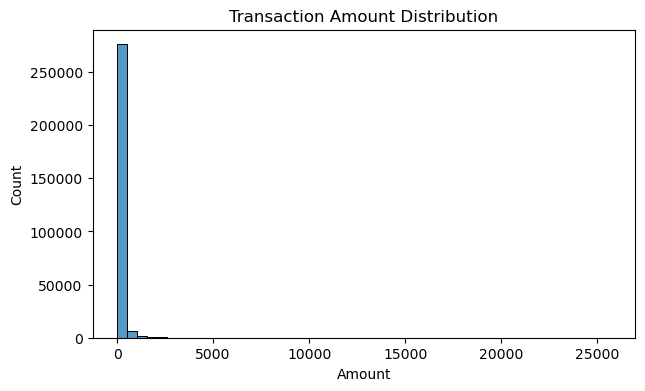

In [25]:
# Visualisation - here we will understand the dataset using graphs

plt.figure(figsize=(7, 4)) #figsize=(width, height) in inches to determine the size of canvas for graph
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()
# This plot shows how transaction amounts are distributed, whether most transactions are low-value or high-value.

The Amount distribution is highly right-skewed. Most transactions have low amounts, while only a few transactions have very high amounts. This indicates the presence of extreme values. Since Amount has a much larger range than the PCA-transformed V1 to V28 features, scaling is required before applying models like K-Means.

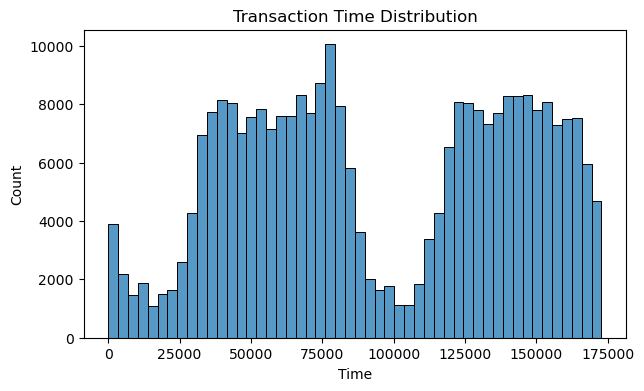

In [24]:
# determining the time period distribution
plt.figure(figsize=(7, 4)) #Creates a new graph area first, then draws the plot inside it.
sns.histplot(df['Time'], bins=50)
plt.title('Transaction Time Distribution')
plt.xlabel('Time')
plt.ylabel('Count')
plt.show()

#Insights:
# this graph shows the transaction distribution throughtout time

In [10]:
df[['Time', 'Amount']].describe() #comparing amount and time desciption

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


### **3. Model Construction**
For this project, model construction has two parts:
1. Isolation Forest - we're asking which of the entries in the dataset are different from others?
2. K-Means Clustering - divides into groups based on which the data points are close enough to whom

Goal: find unusual transactions compared to other usual transactions

### why not K-means?
some datapoints with fraud transactions can hide among the usual transaction groups

In [34]:
# since we're determing fraud or not based on class, we will assign class to another variable 
y = df["Class"]
X = df.drop("Class", axis= 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#ensuring the X without Class is scaled properly among every features 

In [43]:
#using isolation Forest
#ensemble uses many trees 
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination= 0.00173, random_state=42)
# The contamination value is assumed as 0.00173 to detect a small percentage of suspicious transactions.
# around 284,897 transactions, 492 are fraudulent. 492 / 284,897 = 0.001727
iso_labels = iso_forest.fit_predict(X_scaled) 

In [42]:
iso_pred = np.where(iso_labels == -1, 1, 0)

print("Isolation Forest Prediction Counts: ")
print(pd.Series(iso_pred).value_counts())

Isolation Forest Prediction Counts: 
0    284314
1       493
Name: count, dtype: int64


### **4. Conclusion**
Isolation Forest detected 492 transactions as anomalies and 284,315 transactions as normal. The contamination value was set as 0.00173, meaning the model was instructed to identify approximately 0.173% of transactions as suspicious.

This does not confirm that all detected anomalies are actual fraud cases. The actual Class label will be used only in the evaluation section to check how many detected anomalies match real fraud transactions.